<a href="https://colab.research.google.com/drive/1tnOvFNgXiLtktiSsltTr0s308LZSsEPJ">Abre este Jupyter en Google Colab</a>

# Regresión Lineal: Predicción del coste de un incidente de seguridad

En este notebook exploraremos los fundamentos básicos de la **Regresión Lineal** aplicados a un caso de uso práctico de la Ciberseguridad. La regresión lineal nos permite encontrar la relación matemática (una línea recta de tendencia) entre dos variables para poder predecir valores futuros basándonos en datos históricos.

## Enunciado del ejercicio

El objetivo principal es construir un modelo predictivo capaz de estimar el **coste económico de un incidente de seguridad** basándose en el **número de equipos que se han visto afectados** en la red.

*Nota: Para fines didácticos, el conjunto de datos inicial se generará de manera aleatoria. Añadiremos un poco de "ruido" matemático para simular la dispersión y el comportamiento natural de los datos en el mundo real.*

### 0. Instalación e importación de librerías
Antes de comenzar, instalaremos y prepararemos las herramientas fundamentales que requiere Python para análisis de datos y Machine Learning.

In [18]:
# Instalación de librerías externas
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

### 1. Generación del conjunto de datos
Vamos a crear datos sintéticos. La variable `X` representará los equipos afectados y la variable `y` representará el coste del incidente. Usamos una ecuación base y le sumamos ruido aleatorio mediante `np.random.randn()` para que los puntos no formen una línea recta perfecta, lo cual sería irreal.

In [19]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

print("La longitud del conjunto de datos es:", len(X))

La longitud del conjunto de datos es: 100


### 2. Visualización del conjunto de datos
El primer paso en cualquier proyecto de datos es explorar visualmente la información. Esto nos ayuda a confirmar empíricamente si existe una tendencia clara (es decir, verificar si a mayor cantidad de equipos, efectivamente el coste aumenta). Utilizaremos la librería gráfica `matplotlib`.

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

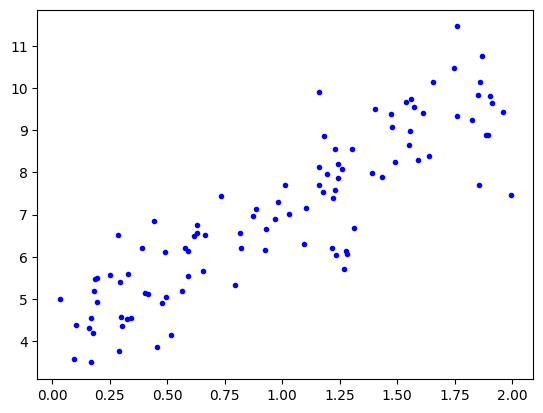

In [21]:
plt.plot(X, y, "b.")
plt.show()

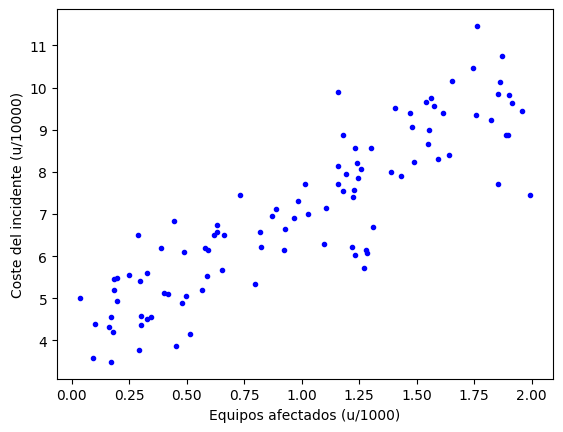

In [22]:
plt.plot(X, y, "b.")
plt.xlabel("Equipos afectados (u/1000)")
plt.ylabel("Coste del incidente (u/10000)")
plt.show()

### 3. Modificación y preparación del conjunto de datos
Para que los datos numéricos que hemos generado tengan un sentido más real en nuestro contexto empresarial, vamos a estructurarlos en una tabla usando `Pandas` y a escalar sus valores multiplicándolos:
- `X` se multiplicará por 1.000 (hablaremos de miles de equipos).
- `y` se multiplicará por 10.000 (representando el impacto financiero en la moneda local).

In [23]:
import pandas as pd

In [24]:
data = {'n_equipos_afectados': X.flatten(), 'coste': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste
0,0.390241,6.196514
1,1.590856,8.297040
2,0.103165,4.382221
3,0.303319,4.365672
4,1.553918,8.993127
5,0.453951,3.868802
6,1.654403,10.154502
7,0.924722,6.150790
8,0.872348,6.955592
9,0.286873,6.512093


In [25]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')
# Escalado del coste
df['coste'] = df['coste'] * 10000
df['coste'] = df['coste'].astype('int')
df.head(10)

,n_equipos_afectados,coste
0,390,61965
1,1590,82970
2,103,43822
3,303,43656
4,1553,89931
5,453,38688
6,1654,101545
7,924,61507
8,872,69555
9,286,65120


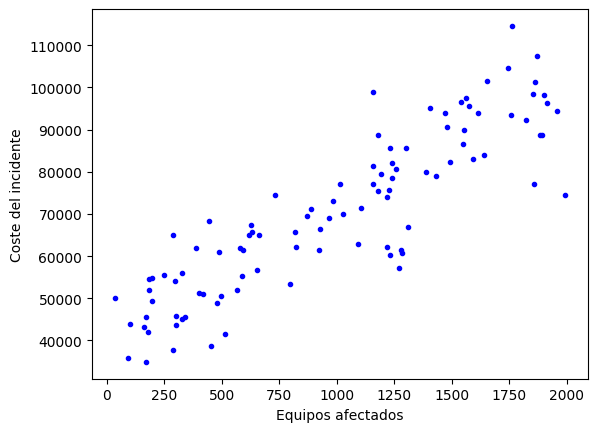

In [26]:
# Representación gráfica del conjunto de datos actualizado
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 4. Construcción y entrenamiento del modelo
Llegó el momento de aplicar **Machine Learning**. Instanciaremos un modelo de `LinearRegression` perteneciente a la librería `scikit-learn`.

Al llamar a la función `fit()`, el algoritmo procesa nuestros datos de entrenamiento e intenta ajustar la ecuación matemática de una línea recta ($y = \theta_0 + \theta_1 x$) que cruce de la mejor manera por en medio de todos nuestros puntos (minimizando los errores).

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
# Construcción del modelo y ajuste de la función hipótesis (entrenamiento)
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1, 1), df['coste'].values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Una vez entrenado, el modelo ha calculado dos parámetros fundamentales.
Primero, obtenemos el **intercepto** ($\theta_0$), que indica teóricamente cuál sería el coste base de un incidente en caso de que los equipos afectados fueran `0` (el punto en el que la recta cruza el eje vertical).

In [29]:
# Parámetro theta 0 (Intersección o punto de partida de la recta)
lin_reg.intercept_

41338.41810948985

A continuación, obtenemos la **pendiente** ($\theta_1$). Este parámetro es crucial porque define la inclinación de la línea, indicándonos aproximadamente cuánto dinero aumenta el coste total por cada equipo adicional que se ve comprometido.

In [30]:
# Parámetro theta 1 (Pendiente de la recta)
lin_reg.coef_

array([29.24436758])

Para trazar la recta que el modelo acaba de aprender, tomaremos los valores mínimos y máximos de los equipos afectados de nuestra tabla y le pediremos al modelo que estime el coste para ambos. Al unir esos dos puntos generados, veremos nuestra línea de regresión.

In [31]:
# Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max)

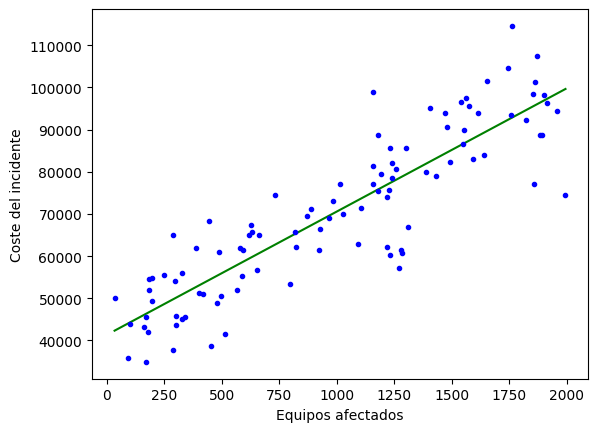

In [32]:
# Representación gráfica de la función hipótesis generada (Línea verde)
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 5. Predicción de nuevos ejemplos (Inferencia)
Ahora que poseemos un modelo de regresión funcional y confiable, podemos utilizarlo para predecir escenarios hipotéticos futuros. Usaremos la función `predict()` para calcular cuál sería el coste estimado si la empresa sufre un incidente que afecta exactamente a **1300 equipos**.

In [33]:
x_new = np.array([[1300]]) # 1300 equipos afectados

# Predicción del coste que tendría el incidente
coste = lin_reg.predict(x_new)

print("El coste del incidente sería:", int(coste[0]), "€")

El coste del incidente sería: 79356 €


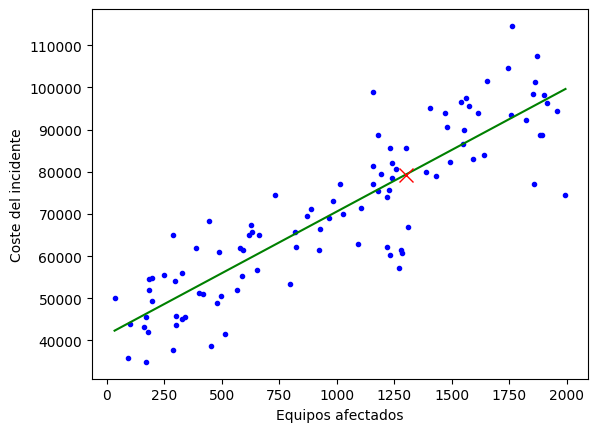

In [34]:
# Graficamos la predicción como un punto rojo (rx) en nuestro mapa de dispersión
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx", markersize=10)
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()